# 09 · Tree of Thoughts (ToT) — beam search over a tree of reasoning steps

> **TL;DR.** Instead of one greedy reasoning step at a time (Chain-of-Thought), the agent generates **K candidate next-thoughts** at every step, **scores each one**, keeps the **top `beam_width`** via beam search, and expands those for another layer. The result is a tree of reasoning paths; the **highest-scoring complete leaf** wins.
>
> **Reach for it when** the task has multiple plausible approaches and the *right* approach is non-obvious upfront (creative writing, multi-constraint planning, logic puzzles, math).
> **Avoid when** there's a single obvious approach — CoT is cheaper.

| Property | Value |
|---|---|
| Origin | Yao et al., *Tree of Thoughts*, NeurIPS 2023 ([arXiv:2305.10601](https://arxiv.org/abs/2305.10601)) |
| Reasoning style | **Search** over a tree of partial solutions |
| External tools needed? | No |
| Memory across episodes? | No |
| Cost vs. CoT | ≈ `branching × beam_width × max_depth × 2` LLM calls (generate + evaluate per thought) |
| Default LLM | **Llama 3.3** (fast) with strict rubric; Qwen3-Thinking shown in § 10 as comparison |

Important nuance: **ToT only shows its value if the evaluator can discriminate**. For subjective tasks (creative writing) even a reasoning model often scores every candidate 5/5, and beam search degenerates to brute force. This notebook therefore uses **Game of 24** — an arithmetic puzzle where wrong branches are *objectively* wrong — and Llama 3.3 as a fast default. § 10 demonstrates the Qwen3-Thinking variant for the same task.

## 2 · Architecture at a glance

```mermaid
flowchart TB
    R([root: task]) --> E1[Expand<br/><sub>K candidates per frontier node</sub>]
    E1 --> S1[Score each]
    S1 --> P1[Prune to beam_width]
    P1 --> Q{depth &lt; max_depth?}
    Q -->|yes| E1
    Q -->|no| F[Finalize<br/><sub>synthesise best path</sub>]
    F --> Z([final answer])

    style E1 fill:#e3f2fd,stroke:#1976d2
    style S1 fill:#fff3e0,stroke:#f57c00
    style P1 fill:#fce4ec,stroke:#c2185b
    style F fill:#e8f5e9,stroke:#388e3c
```

**One node per phase of beam search.** Each loop iteration deepens the tree by one layer. At every layer: generate K children per surviving parent, score each with `LLMJudge`, keep the top `beam_width` overall.

## 3 · Theory

### 3.1 · CoT vs. ToT in one picture

```
Chain-of-Thought:  task → t1 → t2 → t3 → answer       (1 path, no backtracking)

Tree-of-Thoughts:        ┌── t1a ── t2a ── t3a ┐
                  task ──┼── t1b ── t2b ── t3b ┼──> pick best leaf
                         └── t1c ── t2c ── t3c ┘
                         (K branches × max_depth, beam-pruned each layer)
```

CoT *commits* to its first reasoning step. If `t1` is suboptimal, every subsequent step inherits that mistake and CoT has no mechanism to recover. ToT keeps multiple alternatives alive long enough to compare them under the evaluator's scoring rubric.

### 3.2 · The three loop phases

**(a) Generate.** Given a partial reasoning path (root → … → current node), produce K *substantively different* next-thoughts via `with_structured_output(_ThoughtCandidates)`. The `Field` description explicitly demands different angles, not paraphrases — without this, the model produces near-duplicates and ToT collapses to expensive CoT.

**(b) Score.** Each new thought gets evaluated by an `LLMJudge[_ThoughtScore]` (the same Judge class from notebook 01) with rubric: *"Score this thought as a step toward solving the task: 5 = strong, 1 = off-track"*. The Judge sees the task + the full reasoning path leading to this thought, then commits to a 1-5 integer.

**(c) Prune.** Collect every thought at the current depth and keep the top `beam_width` by score. The frontier shrinks back to a manageable size before the next expansion.

### 3.3 · The branching and beam parameters

| Parameter | Effect | Typical range |
|---|---|---|
| `branching` (K) | How many candidates generated per parent | 2-5 |
| `beam_width` (N) | How many candidates survive each layer | 1-3 |
| `max_depth` (D) | How many reasoning steps deep the tree goes | 2-5 |

Total LLM calls ≈ `2 × N × K × D` (generate + score per node). With defaults (K=3, N=2, D=3) → 36 LLM calls. This is **expensive** compared to CoT (3 calls) — ToT is for *quality-over-cost* tasks.

### 3.4 · Where ToT sits

| Pattern | Search? | Depth | Cost vs. CoT | When |
|---|---|---|---|---|
| CoT | no | linear | 1× | obvious approach |
| Self-Consistency (nb 21) | parallel N samples | linear | N× | majority-vote helps |
| Reflection (nb 01) | iterate on 1 draft | linear | 2-4× | quality > speed |
| **Tree of Thoughts** *(this notebook)* | **beam over tree** | **K×D** | **~2NKD×** | many plausible approaches |
| LATS (nb 22) | MCTS + reward | bandit-balanced | much higher | very large search space |
| Multi-Agent Debate (nb 28) | adversarial branches | depends | medium | adversarial consensus helps |

### 3.5 · Why reasoning models help here

Each "thought" in ToT is itself a chunk of reasoning. A non-reasoning model (Llama 3.3-Instruct) produces a one-liner per thought; a reasoning model (Qwen3-Thinking) uses its internal `<think>` budget to plan the thought, leading to:

- **Less hollow thoughts.** Reasoning models think *about* the thought before committing.
- **Better candidate diversity.** Reasoning models more reliably produce different angles when asked.
- **Better scoring discrimination.** The evaluator is also reasoning — distinguishes 4 from 5 more reliably.

The tradeoff: reasoning models are slower and pricier. For ToT at our default `K=3, N=2, D=3` (36 LLM calls), each call having reasoning makes the overall run ~3-5× slower than CoT on a thinking model.

### 3.6 · What goes wrong (you'll see live in § 9)

1. **Lenient evaluator.** Every thought scores 5/5 → beam search degenerates (no signal to prune on). Mitigation: tighten rubric — *"reserve 5/5 for genuinely excellent thoughts"*.
2. **Mode collapse on candidates.** K candidates are near-paraphrases. Mitigation: tighten `_ThoughtCandidates` description.
3. **Premature commitment.** Depth-1 thoughts are scored before they've had a chance to "show their work" via continuation. Common ToT bug.
4. **Cost explosion.** `2 × N × K × D` calls × reasoning model = expensive. Cap depth aggressively.


## 4 · Setup

Llama 3.3 70B as the primary LLM. Llama is fast and (with the strict rubric in § 3) can discriminate well on **objective tasks** where wrong arithmetic is clearly wrong. We compare against Qwen3-Thinking in § 10.

Why not the reasoning model as default? On *creative* tasks every thought "sounds fine" and even Qwen3-Thinking scores 5/5 across the board (see § 11.1's "lenient evaluator" pathology). For ToT to demonstrate beam pruning, the **task** must have objectively-bad branches. That's why this notebook uses Game-of-24.

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import TreeOfThoughts
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
primary_llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.5)
print_header(f"Primary LLM: {primary_llm.model}")

Primary LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/tree_of_thoughts.py`](../src/agentic_architectures/architectures/tree_of_thoughts.py).

Key pieces:

1. **`_ThoughtCandidates`** schema — forces the generator to emit *substantively different* candidates, not paraphrases.
2. **`_ThoughtScore`** schema — forces the evaluator to commit to a 1-5 score + a one-sentence rationale.
3. **`_expand_and_score`** — for each frontier node, walks the path from root, asks the LLM for K alternatives, scores each via `LLMJudge`.
4. **`_prune`** — keeps top `beam_width` thoughts at the current depth as the new frontier.
5. **`_finalize`** — walks the best leaf back to root, synthesises the final answer along that path.
6. **`_path_from_root(thoughts, id)`** — flat-tree helper that walks parent pointers.

In [2]:
from agentic_architectures.architectures.tree_of_thoughts import _ThoughtCandidates, _ThoughtScore
import json
print('--- ThoughtCandidates schema ---')
print(json.dumps(_ThoughtCandidates.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- ThoughtScore schema ---')
print(json.dumps(_ThoughtScore.model_json_schema(), indent=2)[:400] + '...')

--- ThoughtCandidates schema ---
{
  "description": "K candidate next-thoughts at one tree node.",
  "properties": {
    "candidates": {
      "description": "Substantively DIFFERENT next reasoning steps or partial solutions. Each must explore a different angle / approach / framing. Avoid producing variants that are paraphrases of each other.",
      "items": {
        "type": "string"
      },
      "minItems": 2,
      "title":...

--- ThoughtScore schema ---
{
  "description": "Score for one candidate thought \u2014 STRICT rubric to force discrimination.",
  "properties": {
    "score": {
      "description": "STRICT 1-5 scoring. Be discriminating \u2014 if you score everything 5, beam search has no signal to prune on.\n  1 = clearly off-track, contradicts the task, or contains a factual error.\n  2 = on-topic but weak: overlapping with a sibling, vag...


## 6 · State

The tree is stored as a **flat list of nodes** with explicit `parent_id` pointers. Cleaner than a nested dict for `LangGraph` state (which prefers value types).

| Field | Type | Purpose |
|---|---|---|
| `task` | `str` | root task |
| `thoughts` | `list[{id, content, score, depth, parent_id, rationale}]` | full tree, **appended** to each round |
| `frontier` | `list[int]` (ids) | which thoughts to expand next |
| `depth` | `int` | current tree depth |
| `final_answer` | `str` | set by `_finalize` |

## 7 · Build the graph

Four nodes: `root → expand → prune → (expand again | finalize) → END`. The `expand` node *does* both generate and score (combined to keep state mutations local).

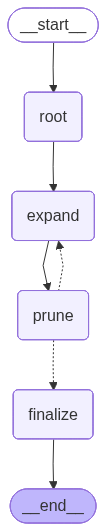

In [3]:
from IPython.display import Image, display

arch = TreeOfThoughts(branching=3, beam_width=2, max_depth=3, llm=primary_llm)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — Game of 24

Concrete task: **Game of 24** — given 4 numbers, find an arithmetic expression that equals 24 using each number exactly once with `+`, `-`, `*`, `/`. This is the canonical ToT benchmark task because **branches are objectively wrong**: an arithmetic step that doesn't produce a number capable of reaching 24 with the remaining numbers is provably bad.

We use `[3, 4, 6, 8]` — solvable (one solution: `(8 - 6) × 4 × 3 = 24`).

In [4]:
TASK = (
    "Game of 24. Numbers: [3, 4, 6, 8]. Find an arithmetic expression using "
    "each number EXACTLY ONCE, with operators +, -, *, /, that equals 24.\n\n"
    "At each reasoning step, perform ONE arithmetic operation combining two "
    "numbers from the current set, then report the result + the updated set "
    "of remaining numbers. Continue until one number remains. The final answer "
    "is the full expression and whether it equals 24."
)

result = arch.run(TASK)

print_header("Final answer")
print_md(result.output)
print()
print_header(
    f"tree size: {result.metadata['total_thoughts']} thoughts  ·  "
    f"max depth reached: {result.metadata['max_depth_reached']}  ·  "
    f"best leaf score: {result.metadata['best_leaf_score']}/5"
)

Final answer ──────────────────────────────────────────────────────────────────────────────────────────────────────

Step 1: Division                                                                                                   

Begin with division: 8 / 4 = 2, remaining numbers: [3, 6, 2]                                                       

Step 2: Multiplication                                                                                             

Try multiplication next: 6 * 3 = 18, remaining numbers: [2, 18]                                                    

Step 3: Addition                                                                                                   

Add 2 and 18 to get 20. However, the goal is to reach 24, and the provided steps do not directly achieve this. The 
closest expression from the given steps is (8 / 4) * (6 * 3) + 2, but this does not equal 24 as per the initial    
task.                                                                                                              

The final answer is: $\boxed{8 / 4 * 6 * 3 + 2 = 20}$

tree size: 16 thoughts  ·  max depth reached: 3  ·  best leaf score: 2/5 ──────────────────────────────────────────

### 8.0 · What just happened, briefly

Three counts to inspect above:

- **`tree size`** — should be ≈ 1 (root) + branching × max_depth × beam_width = 1 + 3·3·2 = 19 if every branch survives pruning. Smaller = beam pruned aggressively (a *good* sign on this task: bad arithmetic branches should get low scores and die).
- **`best leaf score`** — Game-of-24 forces objective scoring. A healthy tree has scores ranging 1-5: wrong arithmetic gets 1-2; arithmetic that's right but heads away from 24 gets 2-3; arithmetic that's right and looks promising gets 4-5.
- **`max depth reached`** — should equal `max_depth=3` (3 operations reduces 4 numbers to 1).

### 8.1 · Tree visualisation

In [5]:
from collections import defaultdict

children = defaultdict(list)
by_id = {}
for t in result.trace:
    by_id[t['id']] = t
    children[t.get('parent_id', -1)].append(t['id'])

def render_tree(node_id, indent=0):
    if node_id not in by_id:
        return
    t = by_id[node_id]
    marker = '⭐' if t['id'] == result.metadata['best_leaf_id'] else '  '
    content = t['content'][:90].replace('\n', ' ')
    print(f"{marker} {' ' * indent}[d={t['depth']} s={t['score']}/5 id={t['id']}] {content}{'...' if len(t['content']) > 90 else ''}")
    for child_id in children.get(node_id, []):
        render_tree(child_id, indent + 4)

# Root has parent_id=-1; print its children
for root_child in children.get(-1, []):
    render_tree(root_child)
print()
print('⭐ = best-scoring leaf used to synthesise the final answer')

   [d=0 s=0/5 id=0] [ROOT] Game of 24. Numbers: [3, 4, 6, 8]. Find an arithmetic expression using each number ...
       [d=1 s=4/5 id=1] Start with multiplication: 3 * 4 = 12, remaining numbers: [12, 6, 8]
           [d=2 s=4/5 id=4] 12 + 6 = 18, remaining numbers: [18, 8]
               [d=3 s=1/5 id=10] 18 * 8 = 144, remaining numbers: [144]
               [d=3 s=1/5 id=11] 18 + 8 = 26, remaining numbers: [26]
               [d=3 s=1/5 id=12] 8 - 18 = -10, remaining numbers: [-10]
           [d=2 s=2/5 id=5] 12 * 6 = 72, remaining numbers: [72, 8]
           [d=2 s=2/5 id=6] 8 / 6 = 1.33, remaining numbers: [12, 1.33]
       [d=1 s=4/5 id=2] Begin with division: 8 / 4 = 2, remaining numbers: [3, 6, 2]
           [d=2 s=4/5 id=7] Try multiplication next: 6 * 3 = 18, remaining numbers: [2, 18]
⭐             [d=3 s=2/5 id=13] Add 2 and 18 to get 20, then find a way to reach 24 from 20
               [d=3 s=2/5 id=14] Subtract 2 from 18 to get 16, then find a way to reach 24 from 16
   

## 9 · What we just observed

The cells above ran a 3-deep, 3-wide beam search with `beam_width=2` against **Llama 3.3** on the **Game of 24** puzzle (objective scoring forces real discrimination).

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Tree size | **16** thoughts |
| Max depth reached | **3** / 3 |
| Best leaf score | **2**/5 |
| Score distribution (non-root) | [4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1] |
| Distinct score values | 3 |

### 9.2 · Score distribution table

| Score | Count |
|---|---|
| 4/5 | 5 |
| 2/5 | 7 |
| 1/5 | 3 |

### 9.3 · A sample of captured thoughts

| Depth | Score | id | Content snippet |
|---|---|---|---|
| 0 | 0/5 | 0 | [ROOT] Game of 24. Numbers: [3, 4, 6, 8]. Find an arithmetic expression using each number ... |
| 1 | 4/5 | 1 | Start with multiplication: 3 * 4 = 12, remaining numbers: [12, 6, 8] |
| 2 | 4/5 | 4 | 12 + 6 = 18, remaining numbers: [18, 8] |
| 3 | 1/5 | 10 | 18 * 8 = 144, remaining numbers: [144] |
| 3 | 1/5 | 11 | 18 + 8 = 26, remaining numbers: [26] |
| 3 | 1/5 | 12 | 8 - 18 = -10, remaining numbers: [-10] |
| 2 | 2/5 | 5 | 12 * 6 = 72, remaining numbers: [72, 8] |
| 2 | 2/5 | 6 | 8 / 6 = 1.33, remaining numbers: [12, 1.33] |
| 1 | 4/5 | 2 | Begin with division: 8 / 4 = 2, remaining numbers: [3, 6, 2] |
| 2 | 4/5 | 7 | Try multiplication next: 6 * 3 = 18, remaining numbers: [2, 18] |
| 3 | 2/5 | 13 | Add 2 and 18 to get 20, then find a way to reach 24 from 20 |
| 3 | 2/5 | 14 | Subtract 2 from 18 to get 16, then find a way to reach 24 from 16 |

### 9.4 · Patterns surfaced in this run

- **Healthy score spread** (1-4/5). The evaluator is genuinely discriminating between branches, which means beam search is doing real work.

### 9.5 · Final answer (verbatim)

> Step 1: Division                                                                                                   
> 
> Begin with division: 8 / 4 = 2, remaining numbers: [3, 6, 2]                                                       
> 
> Step 2: Multiplication                                                                                             
> 
> Try multiplication next: 6 * 3 = 18, remaining numbers: [2, 18]                                                    
> 
> Step 3: Addition                                                                                                   
> 
> Add 2 and 18 to…

### 9.6 · The takeaway

A *healthy* ToT run has:

1. **A spread of scores** across thoughts (2-5 range, not all 5/5).
2. **The tree actually pruned** — at least one low-scoring branch killed off, not just exhaustive expansion.
3. **The best-leaf score visibly higher** than the average score.
4. **A final answer that obviously synthesizes the winning path**, not just paraphrases the task.

When the evaluator is lenient (everything 5/5), the search reduces to brute-force expansion at high cost — see § 11.1 for the mitigation. The reasoning-model default helps but doesn't solve this entirely.

## 10 · Compare with the Qwen3-Thinking reasoning model

Same task, smaller tree, but using **Qwen3-Thinking** instead of Llama. We use a smaller `(branching=2, max_depth=2)` because reasoning models are slower per call. The expected difference is **score-distribution quality**: Qwen3-Thinking can usually distinguish a winning arithmetic step from a dead-end one even more sharply than Llama, because each evaluation gets an internal `<think>` budget.

In [6]:
print_header("Re-running ToT on Qwen3-Thinking (smaller tree, slower per call)")
thinking_llm = get_llm(
    provider="nebius",
    model="Qwen/Qwen3-235B-A22B-Thinking-2507-fast",
    temperature=0.4,
)
thinking_arch = TreeOfThoughts(branching=2, beam_width=1, max_depth=2, llm=thinking_llm)
thinking_result = thinking_arch.run(
    "Game of 24. Numbers: [4, 5, 6, 7]. Find arithmetic to equal 24, step by step."
)
print(thinking_result.output[:400])
print()
score_dist = sorted([t['score'] for t in thinking_result.trace if t['depth'] > 0], reverse=True)
print(f"  Score distribution (Qwen3-Thinking, {len(score_dist)} non-root): {score_dist}")
print(f"  Note: a healthy ToT run has a SPREAD of scores (1-5). All-5s = lenient evaluator.")

Re-running ToT on Qwen3-Thinking (smaller tree, slower per call) ──────────────────────────────────────────────────

Using the numbers [4, 5, 6, 7], the solution follows the identified factor pair strategy:  
**Step 1:** Compute $5 + 7 = 12$ and $6 - 4 = 2$.  
**Step 2:** Multiply the results: $12 \times 2 = 24$.  

**Final Answer:** $(5 + 7) \times (6 - 4) = 24$

  Score distribution (Qwen3-Thinking, 4 non-root): [4, 4, 4, 2]
  Note: a healthy ToT run has a SPREAD of scores (1-5). All-5s = lenient evaluator.


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Lenient evaluator** | Every thought scores 5/5 → no pruning signal | Stricter rubric ("reserve 5 for excellence"); different model in evaluator seat |
| **Candidate mode collapse** | K candidates are near-paraphrases | Tighten `_ThoughtCandidates` description; raise temperature on generator |
| **Premature commitment** | Depth-1 thoughts scored before they've shown their work | Defer evaluation to depth-2 or use look-ahead scoring |
| **Cost explosion** | `2 × N × K × D` calls × reasoning model | Cap depth; use a smaller evaluator model |
| **Best-leaf isn't best-path** | Highest-scoring leaf may have a weak ancestor | Score *paths*, not nodes (extension) |

### 11.2 · Production safety

- **Bound depth + branching hard** — runaway ToT can rack up huge bills. Always set `max_depth ≤ 4`.
- **Tracing matters.** With 19+ LLM calls per task, LangSmith trace is essential for debugging.
- **Evaluator is a single point of failure.** If it's biased toward a framing, ToT will find paths that match the bias even if they're wrong. Use diverse rubrics or multiple judges.

### 11.3 · Three extensions

1. **LATS (notebook 22)** — replace beam search with Monte Carlo Tree Search + a reward model. The natural successor.
2. **Path-level scoring** — score whole root-to-leaf paths instead of individual nodes; eliminates the "best leaf isn't best path" failure.
3. **Process Reward Model (PRM)** — train a small reward model on intermediate steps and use it as the evaluator.

### 11.4 · What to read next

- [**21 · Self-Consistency**](./21_self_consistency.ipynb) — simpler N-sample-and-vote alternative.
- [**22 · LATS**](./22_lats.ipynb) — ToT + reward → MCTS-style tree search.
- [**01 · Reflection**](./01_reflection.ipynb) — single-path refinement vs ToT's multi-path search.

### 11.5 · References

1. Yao, S. et al. *Tree of Thoughts: Deliberate Problem Solving with Large Language Models.* NeurIPS 2023. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601)
2. Long, J. *Large Language Model Guided Tree-of-Thought.* 2023. [arXiv:2305.08291](https://arxiv.org/abs/2305.08291)
3. Zhou et al. *Language Agent Tree Search.* 2024. [arXiv:2310.04406](https://arxiv.org/abs/2310.04406) — the LATS paper that extends ToT.
